# Лабораторная работа 10
## Лебедева Анна

Установка PySpark

In [7]:
!pip install -q pyspark findspark

Запуск

In [4]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()
print("Spark запущен:", spark.version)

Spark запущен: 4.1.1


Скачиваем датасет iris

In [5]:
df = spark.read.csv("iris.csv", inferSchema=True, header=True)
df.show(5)

+------------+-----------+------------+-----------+-------+
|sepal.length|sepal.width|petal.length|petal.width|variety|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


2. Для каждого типа цветка определите максимальное, минимальное и среднее значение 4-х параметров

In [11]:
from pyspark.sql.functions import max, min, avg, round
from pyspark.sql.functions import col

stats = df.groupBy("variety").agg(
    round(min(col("`sepal.length`")), 2).alias("min_sepal_len"),
    round(max(col("`sepal.length`")), 2).alias("max_sepal_len"),
    round(avg(col("`sepal.length`")), 2).alias("avg_sepal_len"),

    round(min(col("`sepal.width`")), 2).alias("min_sepal_wid"),
    round(max(col("`sepal.width`")), 2).alias("max_sepal_wid"),
    round(avg(col("`sepal.width`")), 2).alias("avg_sepal_wid"),

    round(min(col("`petal.length`")), 2).alias("min_petal_len"),
    round(max(col("`petal.length`")), 2).alias("max_petal_len"),
    round(avg(col("`petal.length`")), 2).alias("avg_petal_len"),

    round(min(col("`petal.width`")), 2).alias("min_petal_wid"),
    round(max(col("`petal.width`")), 2).alias("max_petal_wid"),
    round(avg(col("`petal.width`")), 2).alias("avg_petal_wid"),
)
stats.show()

+----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+
|   variety|min_sepal_len|max_sepal_len|avg_sepal_len|min_sepal_wid|max_sepal_wid|avg_sepal_wid|min_petal_len|max_petal_len|avg_petal_len|min_petal_wid|max_petal_wid|avg_petal_wid|
+----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+
| Virginica|          4.9|          7.9|         6.59|          2.2|          3.8|         2.97|          4.5|          6.9|         5.55|          1.4|          2.5|         2.03|
|    Setosa|          4.3|          5.8|         5.01|          2.3|          4.4|         3.43|          1.0|          1.9|         1.46|          0.1|          0.6|         0.25|
|Versicolor|          4.9|          7.0|         5.94|          2.0|          3.4|         2.77

3. Визуализируйте точечный график (plt.scatter) по каждой паре параметров

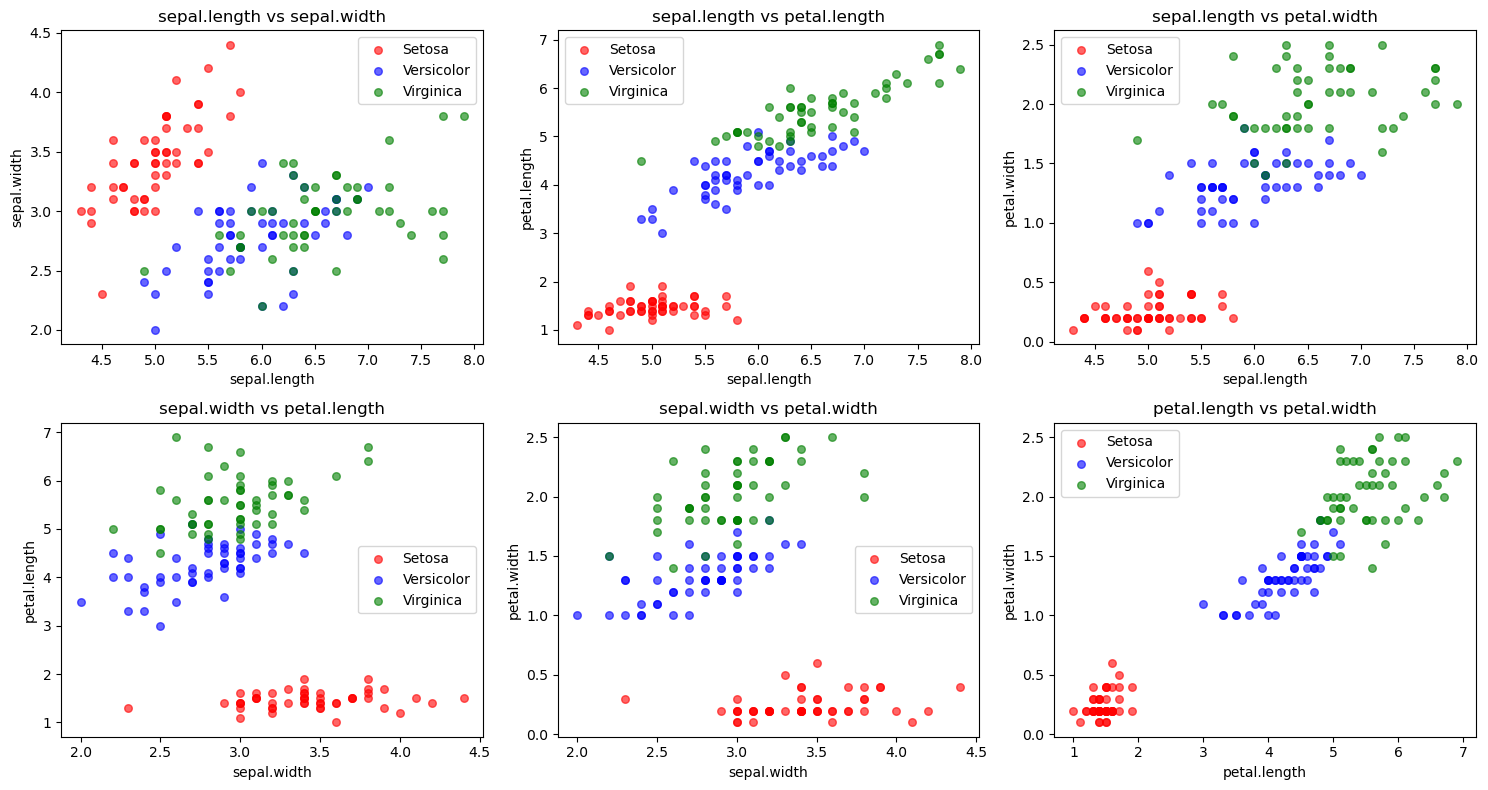

In [12]:
import matplotlib.pyplot as plt

pd_df = df.toPandas()

features = ["sepal.length", "sepal.width", "petal.length", "petal.width"]
colors = {"Setosa": "red", "Versicolor": "blue", "Virginica": "green"}

pairs = [(features[i], features[j]) for i in range(len(features)) for j in range(i+1, len(features))]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (x, y) in enumerate(pairs):
    for variety, group in pd_df.groupby("variety"):
        axes[idx].scatter(group[x], group[y], label=variety, 
                         color=colors[variety], alpha=0.6, s=30)
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
    axes[idx].legend()
    axes[idx].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

4. Попробуйте отделить какой-нить тип цветка от всех остальных (сформулируйте правило на основе диаграммы - ЕСЛИ ЗНАЧЕНИЕ ПАРАМЕТРА X БОЛЬШЕ/МЕНЬШЕ Y, ТО ЦВЕТОК СКОРЕЕ ВСЕГО ОТНОСИТСЯ/НЕ ОТНОСИТСЯ К ТИПУ Z)

In [13]:
# По графикам видно:
# Setosa имеет очень маленькие лепестки (petal.length < 2.5)
# Virginica имеет широкие лепестки (petal.width >= 1.8)
# Остальное — Versicolor

# Вывод правила текстом
print("Правило:")
print("если petal.length < 2.5  → Setosa")
print("если petal.width >= 1.8  → Virginica")
print("иначе → Versicolor")

Правило:
если petal.length < 2.5  → Setosa
если petal.width >= 1.8  → Virginica
иначе → Versicolor


5. Сделайте отдельную колонку для своего предсказания

In [14]:
from pyspark.sql.functions import when, col

df_pred = df.withColumn(
    "prediction",
    when(col("`petal.length`") < 2.5, "Setosa")
    .when(col("`petal.width`") >= 1.8, "Virginica")
    .otherwise("Versicolor")
)

df_pred.show(10)

+------------+-----------+------------+-----------+-------+----------+
|sepal.length|sepal.width|petal.length|petal.width|variety|prediction|
+------------+-----------+------------+-----------+-------+----------+
|         5.1|        3.5|         1.4|        0.2| Setosa|    Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|    Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|    Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|    Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|    Setosa|
|         5.4|        3.9|         1.7|        0.4| Setosa|    Setosa|
|         4.6|        3.4|         1.4|        0.3| Setosa|    Setosa|
|         5.0|        3.4|         1.5|        0.2| Setosa|    Setosa|
|         4.4|        2.9|         1.4|        0.2| Setosa|    Setosa|
|         4.9|        3.1|         1.5|        0.1| Setosa|    Setosa|
+------------+-----------+------------+-----------+-------+----------+
only s

6. Оцените качество (сколько раз Вы угадали с ответом и сколько раз не угадали)

In [15]:
total = df_pred.count()
correct = df_pred.filter(col("prediction") == col("variety")).count()
wrong = total - correct

pct_correct = correct / total * 100
pct_wrong = wrong / total * 100

print(f"Всего цветков: {total}")
print(f"Угадал: {correct}  ({pct_correct:.1f}%)")
print(f"Не угадал: {wrong}  ({pct_wrong:.1f}%)")

Всего цветков: 150
Угадал: 144  (96.0%)
Не угадал: 6  (4.0%)
